In [212]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

In [213]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [214]:
URL = r"https://www.dropbox.com/s/qhhlqcica1nvtaw/opencv_bootcamp_assets_NB1.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB1.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

In [215]:
#Display 18X18
Image(filename="checkerboard_18x18.png")

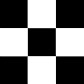

In [216]:
#Display 84X84
Image(filename='checkerboard_84x84.jpg')

In [217]:
#Read image in grey scale
cb_img = cv2.imread('checkerboard_18x18.png', 0)
print(cb_img)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

In [218]:
#Display img


In [219]:
#Data type
print('Image size is', cb_img.shape)

print('Image type is', cb_img.dtype)

Image size is (18, 18)
Image type is uint8


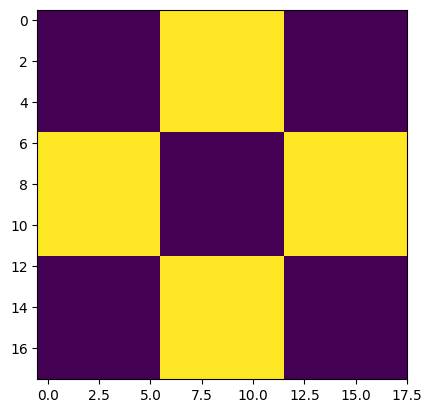

In [220]:
#Plot numpy array to represent image
plt.imshow(cb_img)

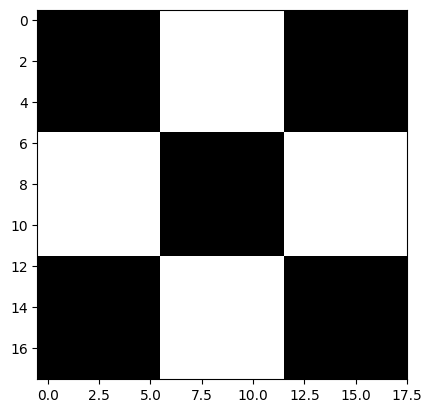

In [221]:
#set up color map to get original img
plt.imshow(cb_img, cmap='gray')

[[  0   0  15  20   1 134 233 253 253 253 255 229 130   1  29   2   0   0]
 [  0   1   5  18   0 137 232 255 254 247 255 228 129   0  24   2   0   0]
 [  7   5   2  28   2 139 230 254 255 249 255 226 128   0  27   3   2   2]
 [ 25  27  28  38   0 129 236 255 253 249 251 227 129   0  36  27  27  27]
 [  2   0   0   4   2 130 239 254 254 254 255 230 126   0   4   2   0   0]
 [132 129 131 124 121 163 211 226 227 225 226 203 164 125 125 129 131 131]
 [234 227 230 229 232 205 151 115 125 124 117 156 205 232 229 225 228 228]
 [254 255 255 251 255 222 102   1   0   0   0 120 225 255 254 255 255 255]
 [254 255 254 255 253 225 104   0  50  46   0 120 233 254 247 253 251 253]
 [252 250 250 253 254 223 105   2  45  50   0 127 223 255 251 255 251 253]
 [254 255 255 252 255 226 104   0   1   1   0 120 229 255 255 254 255 255]
 [233 235 231 233 234 207 142 106 108 102 108 146 207 235 237 232 231 231]
 [132 132 131 132 130 175 207 223 224 224 224 210 165 134 130 136 134 134]
 [  1   1   3   0   0 129

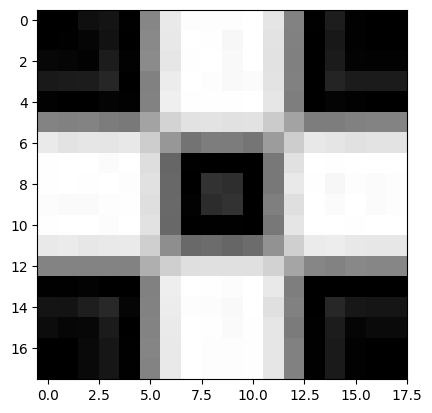

In [222]:
cb_img_fuzzy = cv2.imread('checkerboard_fuzzy_18x18.jpg', 0)
print(cb_img_fuzzy)

plt.imshow(cb_img_fuzzy, cmap='gray')

Color Images

In [223]:
cola = cv2.imread('coca-cola-logo.png', 1)

print('Image size is', cola.shape) #3 is number of channels

print('Image type is', cola.dtype)

Image size is (700, 700, 3)
Image type is uint8


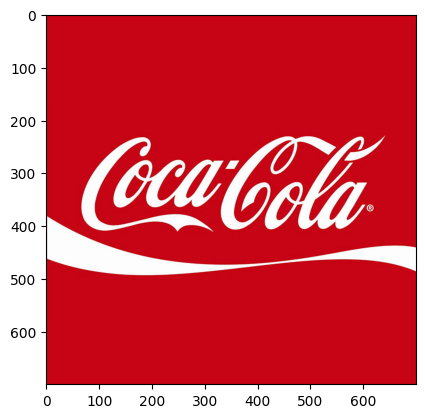

In [224]:
cola = cv2.cvtColor(cola, cv2.COLOR_BGR2RGB)
plt.imshow(cola)

Splitting and Merging Color Channels

cv2.split() Divides a multi-channel array into several single-channel arrays.

cv2.merge() Merges several arrays to make a single multi-channel array. All the input matrices must have the same size.

Text(0.5, 1.0, 'Merged Output')

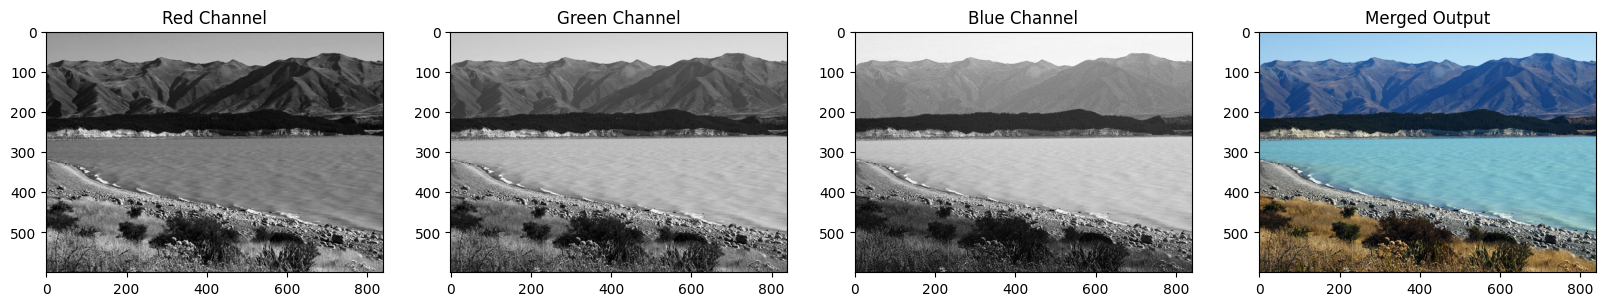

In [225]:
img_NZ_BGR = cv2.imread('New_Zealand_Lake.jpg', cv2.IMREAD_COLOR)
b,g,r = cv2.split(img_NZ_BGR)

plt.figure(figsize=[20, 5])

plt.subplot(141);plt.imshow(r, cmap="gray");plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap="gray");plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap="gray");plt.title("Blue Channel")

# Merge the individual channels into a BGR image
imgMerged = cv2.merge((b, g, r))
# Show the merged output
plt.subplot(144)
plt.imshow(imgMerged[:, :, ::-1])
plt.title("Merged Output")

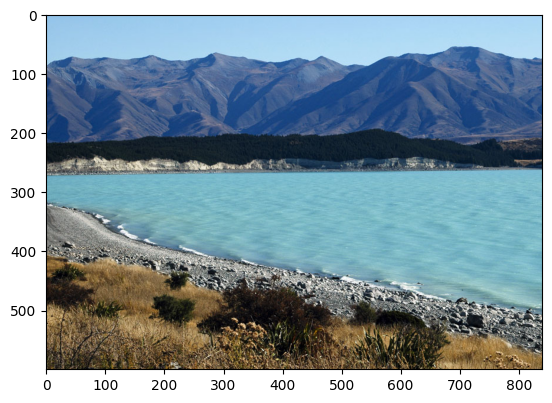

In [226]:
#Change BGR to RGB
nz_RGB = cv2.cvtColor(img_NZ_BGR, cv2.COLOR_BGR2RGB)
plt.imshow(nz_RGB)

# 📷 Basic Image Manipulations

## 🔹 1. Accessing and Manipulating Image Pixels  
- Reading an image  
- Accessing individual pixels  
- Modifying pixel values  

## 🔹 2. Image Resizing  
- Scaling an image up or down  
- Maintaining aspect ratio  
- Interpolation techniques  

## 🔹 3. Cropping an Image  
- Selecting a region of interest (ROI)  
- Extracting and saving a cropped section  

## 🔹 4. Flipping an Image  
- Horizontal flipping  
- Vertical flipping  
- Rotating images  

In [227]:
URL = r"https://www.dropbox.com/s/rys6f1vprily2bg/opencv_bootcamp_assets_NB2.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB2.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

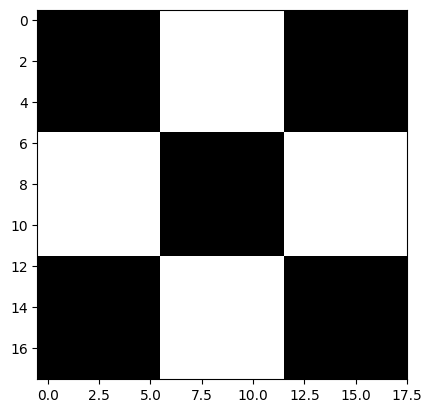

In [228]:
cb_img = cv2.imread("checkerboard_18x18.png", 0)

plt.imshow(cb_img, cmap="gray")
print(cb_img)

In [229]:
#Zero row zero column
print(cb_img[0,0])
#Zero row 6th column
print(cb_img[0,6])

0
255


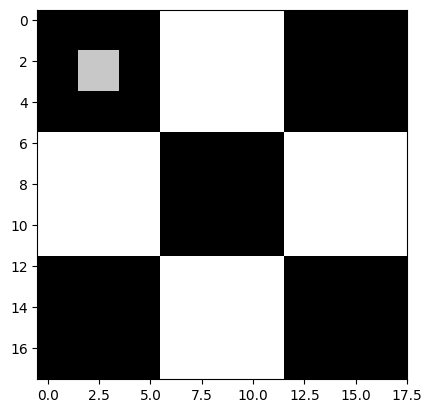

In [230]:
#Pixels modification

cb_img_copy = cb_img.copy()

cb_img_copy[2,2] = 200
cb_img_copy[2,3] = 200
cb_img_copy[3,2] = 200
cb_img_copy[3,3] = 200

plt.imshow(cb_img_copy, cmap='gray')

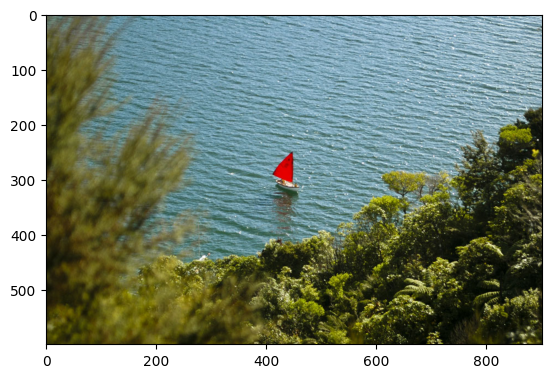

In [231]:
#Cropping img
img_NZ_bgr = cv2.imread("New_Zealand_Boat.jpg")
img_NZ_RGB = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_NZ_RGB)

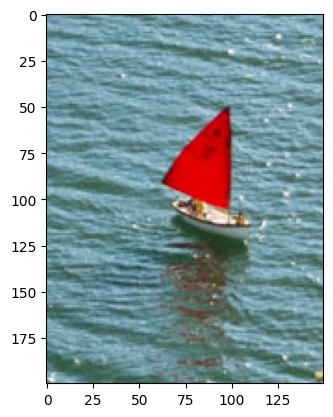

In [232]:
boat_cropped = img_NZ_RGB[200:400, 350:500]
plt.imshow(boat_cropped)

# 📌 Interpolation Method in `cv2.resize()`

The **interpolation method parameter** in `cv2.resize()` determines **how pixel values are computed when resizing an image**.  
It **does not specify** the output size or scaling factor; instead, it defines the **algorithm used to estimate new pixel values**.

---

## 🔹 Interpolation Methods in OpenCV  

Some common interpolation methods used in `cv2.resize()` are:

- **`cv2.INTER_NEAREST`** → Nearest-neighbor interpolation (**fastest, lowest quality**).
- **`cv2.INTER_LINEAR`** → Bilinear interpolation (**default, commonly used**).
- **`cv2.INTER_CUBIC`** → Bicubic interpolation (**higher quality, slower**).
- **`cv2.INTER_LANCZOS4`** → Lanczos interpolation (**best quality, slowest**).

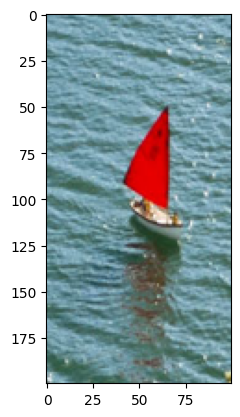

In [233]:
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)

resized_cropped_region = cv2.resize(boat_cropped, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

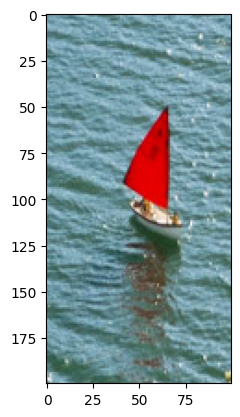

In [234]:
resized_cropped_region = cv2.resize(boat_cropped, dsize=dim, interpolation=cv2.INTER_LANCZOS4)
plt.imshow(resized_cropped_region)

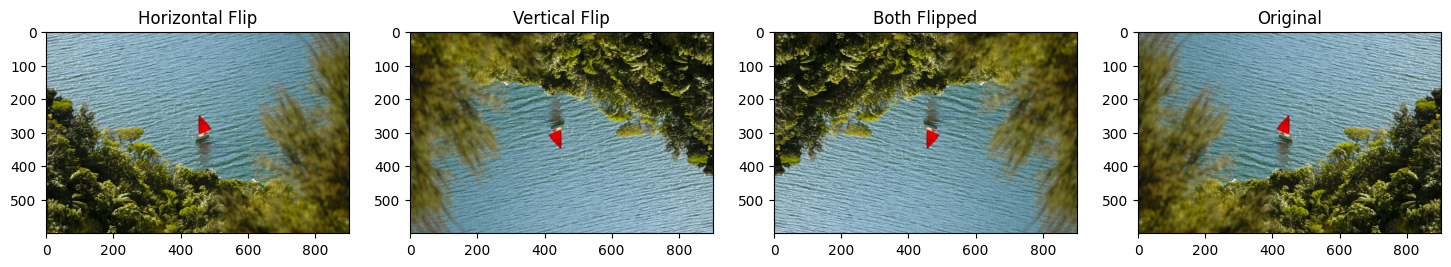

In [235]:
#Flip
img_NZ_RGB_flip_horizontally = cv2.flip(img_NZ_RGB, 1)
img_NZ_RGB_flip_vertically = cv2.flip(img_NZ_RGB, 0)
img_NZ_RGB_flip_both = cv2.flip(img_NZ_RGB, -1)

plt.figure(figsize=(18, 5))
plt.subplot(141);plt.imshow(img_NZ_RGB_flip_horizontally);plt.title("Horizontal Flip");
plt.subplot(142);plt.imshow(img_NZ_RGB_flip_vertically);plt.title("Vertical Flip");
plt.subplot(143);plt.imshow(img_NZ_RGB_flip_both);plt.title("Both Flipped");
plt.subplot(144);plt.imshow(img_NZ_RGB);plt.title("Original");

Lines

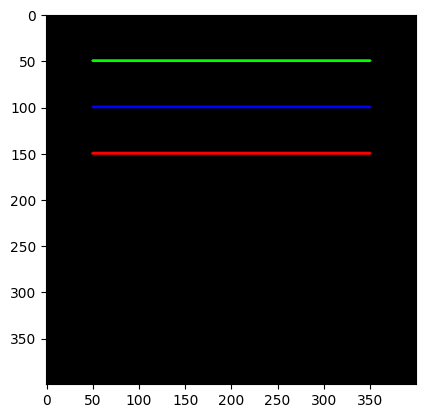

In [236]:
img = np.zeros((400, 400, 3), dtype=np.uint8)

# Draw lines with different line types
cv2.line(img, (50, 50), (350, 50), (0, 255, 0), 2, cv2.LINE_4)   # 4-connected
cv2.line(img, (50, 100), (350, 100), (0, 0, 255), 2, cv2.LINE_8)  # 8-connected
cv2.line(img, (50, 150), (350, 150), (255, 0, 0), 2, cv2.LINE_AA) # Anti-aliased

# Show the image
plt.imshow(img)

Basic Image Enhancement Using Mathematical Operations

In [237]:
URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB4.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

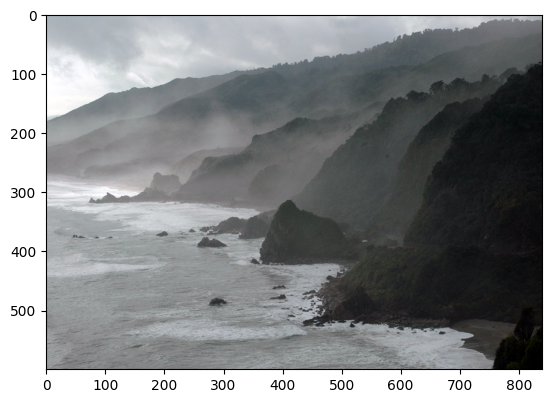

In [238]:
img = cv2.imread('New_Zealand_Coast.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [239]:
print('Image size is', img.shape)

Image size is (600, 840, 3)


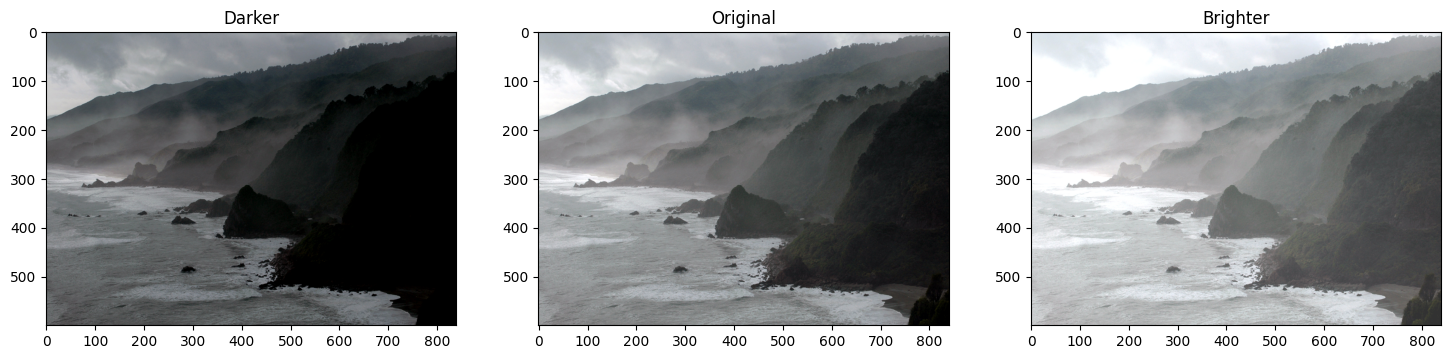

In [240]:
#Brightness
matrix = np.ones(img.shape, dtype='uint8') * 50

img_brighter = cv2.add(img, matrix)
img_darker = cv2.subtract(img, matrix)

plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img);         plt.title("Original");
plt.subplot(133); plt.imshow(img_brighter);plt.title("Brighter");

Text(0.5, 1.0, 'Higher Contrast')

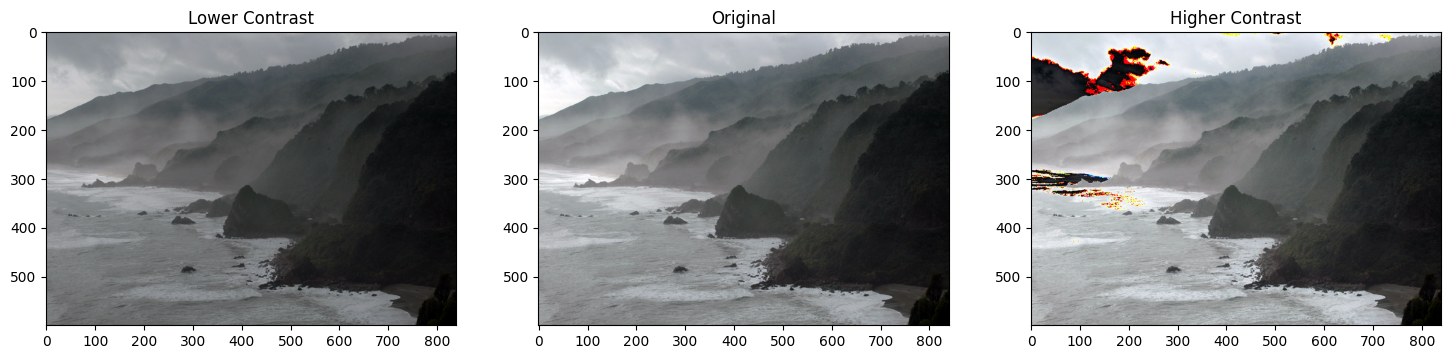

In [241]:
#Contrast
matrix_low_contrast = np.ones(img.shape) * 0.8
matrix_high_contrast = np.ones(img.shape) * 1.2

img_darker = np.uint8(cv2.multiply(np.float64(img), matrix_low_contrast))
img_brighter = np.uint8(cv2.multiply(np.float64(img), matrix_high_contrast))

plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_darker);  plt.title("Lower Contrast")
plt.subplot(132); plt.imshow(img);         plt.title("Original")
plt.subplot(133); plt.imshow(img_brighter);plt.title("Higher Contrast")

Black on high contrast is the reasult that number of pxl were close to 255 and after being multiplyed by 1.2 it went over 255 to solve it we need to specify range

Text(0.5, 1.0, 'Higher Contrast')

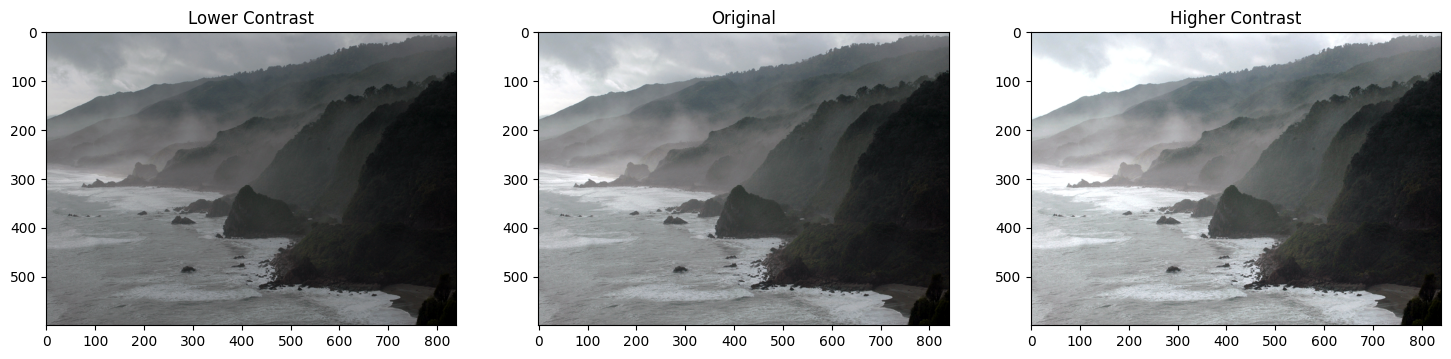

In [242]:
img_darker = np.uint8(cv2.multiply(np.float64(img), matrix_low_contrast))
img_brighter = np.uint8(np.clip(cv2.multiply(np.float64(img), matrix_high_contrast), 0, 255))

plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_darker);  plt.title("Lower Contrast")
plt.subplot(132); plt.imshow(img);         plt.title("Original")
plt.subplot(133); plt.imshow(img_brighter);plt.title("Higher Contrast")

## Image Thresholding
Binary Images have a lot of use cases in Image Processing. One of the most common use cases is that of creating masks. Image Masks allow us to process on specific parts of an image keeping the other parts intact. Image Thresholding is used to create Binary Images from grayscale images. You can use different thresholds to create different binary images from the same original image.

### <font color="green">Function Syntax </font>

``` python
retval, dst = cv2.threshold( src, thresh, maxval, type[, dst] )
```

`dst`: The output array of the same size and type and the same number of channels as `src`.

The function has **4 required arguments**:

1. `src`: input array (multiple-channel, 8-bit or 32-bit floating point).

2. `thresh`: threshold value.

3. `maxval`: maximum value to use with the THRESH_BINARY and THRESH_BINARY_INV thresholding types.

4. `type`: thresholding type (see ThresholdTypes).


### <font color="green">Function Syntax </font>

``` python
dst = cv.adaptiveThreshold( src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst] )
```

`dst`	Destination image of the same size and the same type as src.

The function has **6 required arguments**:
1. `src`:	Source 8-bit single-channel image.

2. `maxValue`:	Non-zero value assigned to the pixels for which the condition is satisfied

3. `adaptiveMethod`:	Adaptive thresholding algorithm to use, see AdaptiveThresholdTypes. The BORDER_REPLICATE | BORDER_ISOLATED is used to process boundaries.

4. `thresholdType:`	Thresholding type that must be either THRESH_BINARY or THRESH_BINARY_INV, see ThresholdTypes.

5. `blockSize`:	Size of a pixel neighborhood that is used to calculate a threshold value for the pixel: 3, 5, 7, and so on.

6. `C`:	Constant subtracted from the mean or weighted mean (see the details below). Normally, it is positive but may be zero or negative as well.

### <font style="color:rgb(8,133,37)">OpenCV Documentation</font>

<a href="https://docs.opencv.org/4.5.1/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57
https://docs.opencv.org/4.5.1/d7/d4d/tutorial_py_thresholding.html" target="_blank">Documentation link</a>

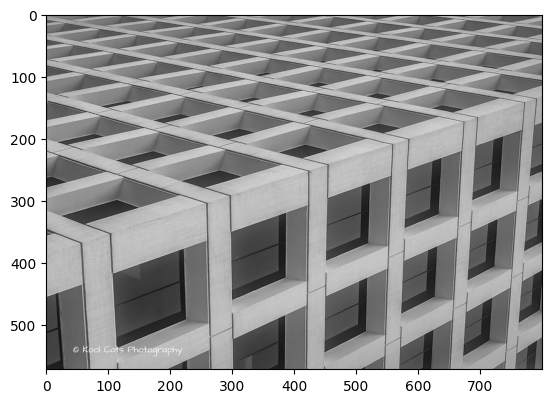

In [243]:
img = cv2.imread('building-windows.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')

(572, 800)


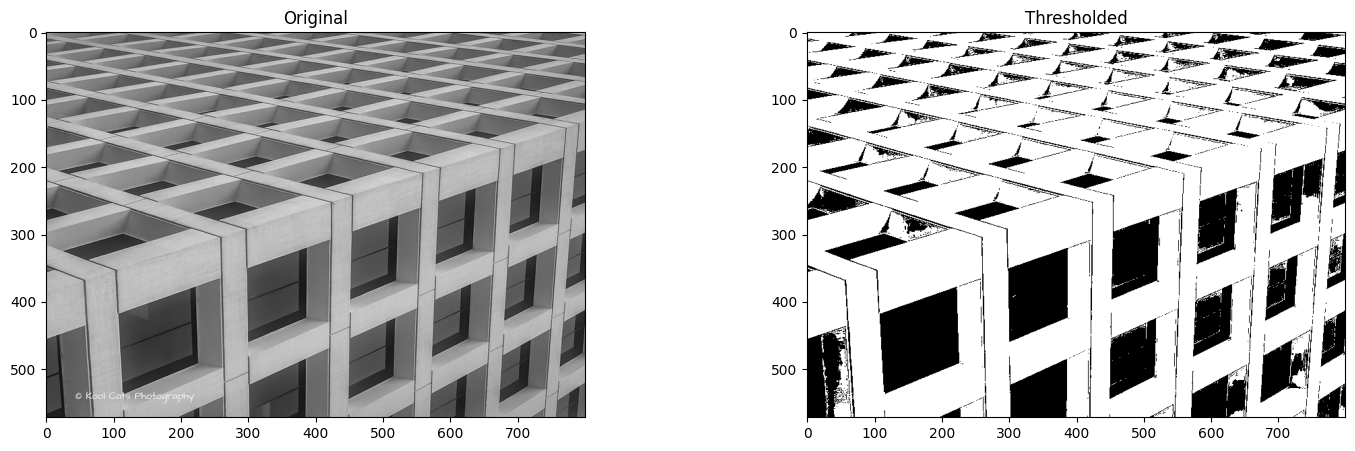

In [244]:
#Threshold
retval, img_thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

print(img_thresh.shape)

(572, 800)


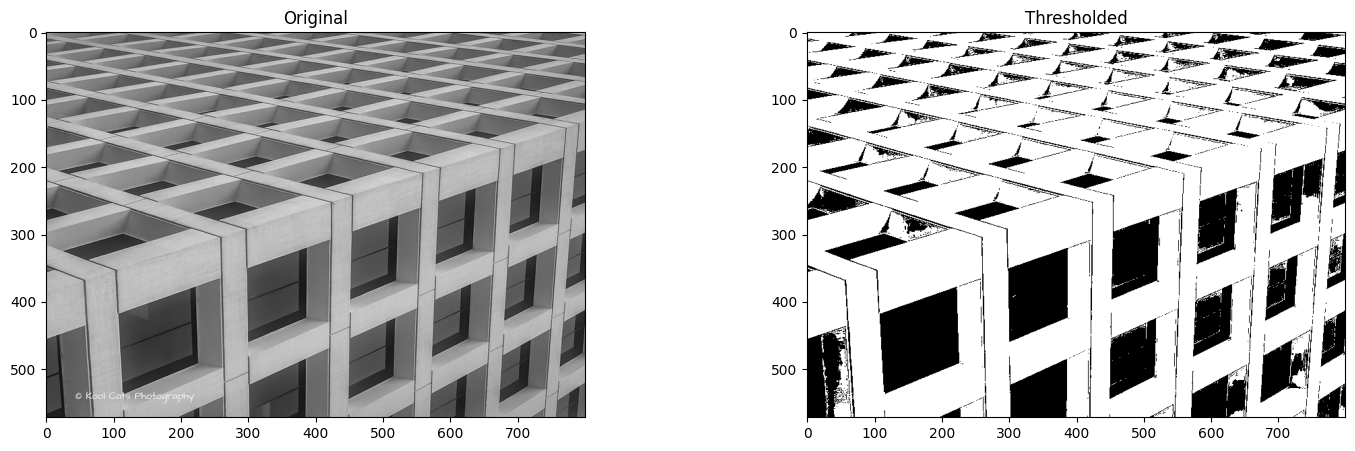

In [245]:
#Threshold 
retval, img_thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

print(img_thresh.shape)

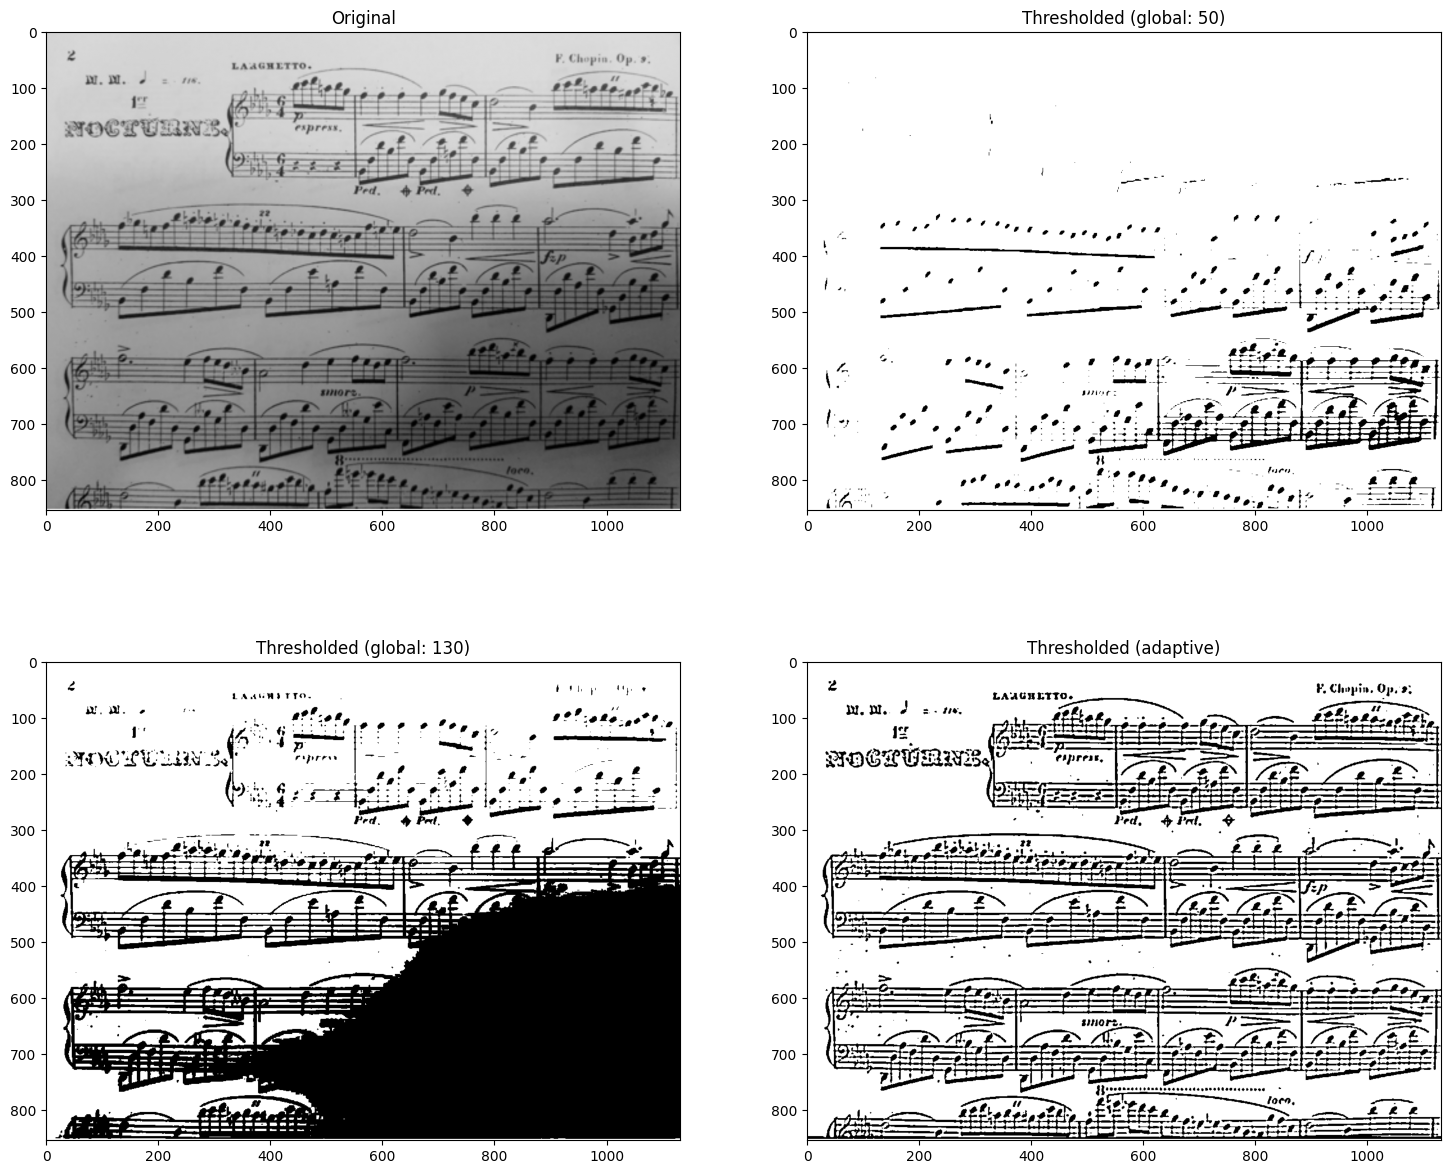

In [246]:
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

# Perform global thresholding
retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)

# Perform global thresholding
retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)

# Perform adaptive thresholding, different strcutre of commands
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

Text(0.5, 1.0, 'Adaptive Threshold')

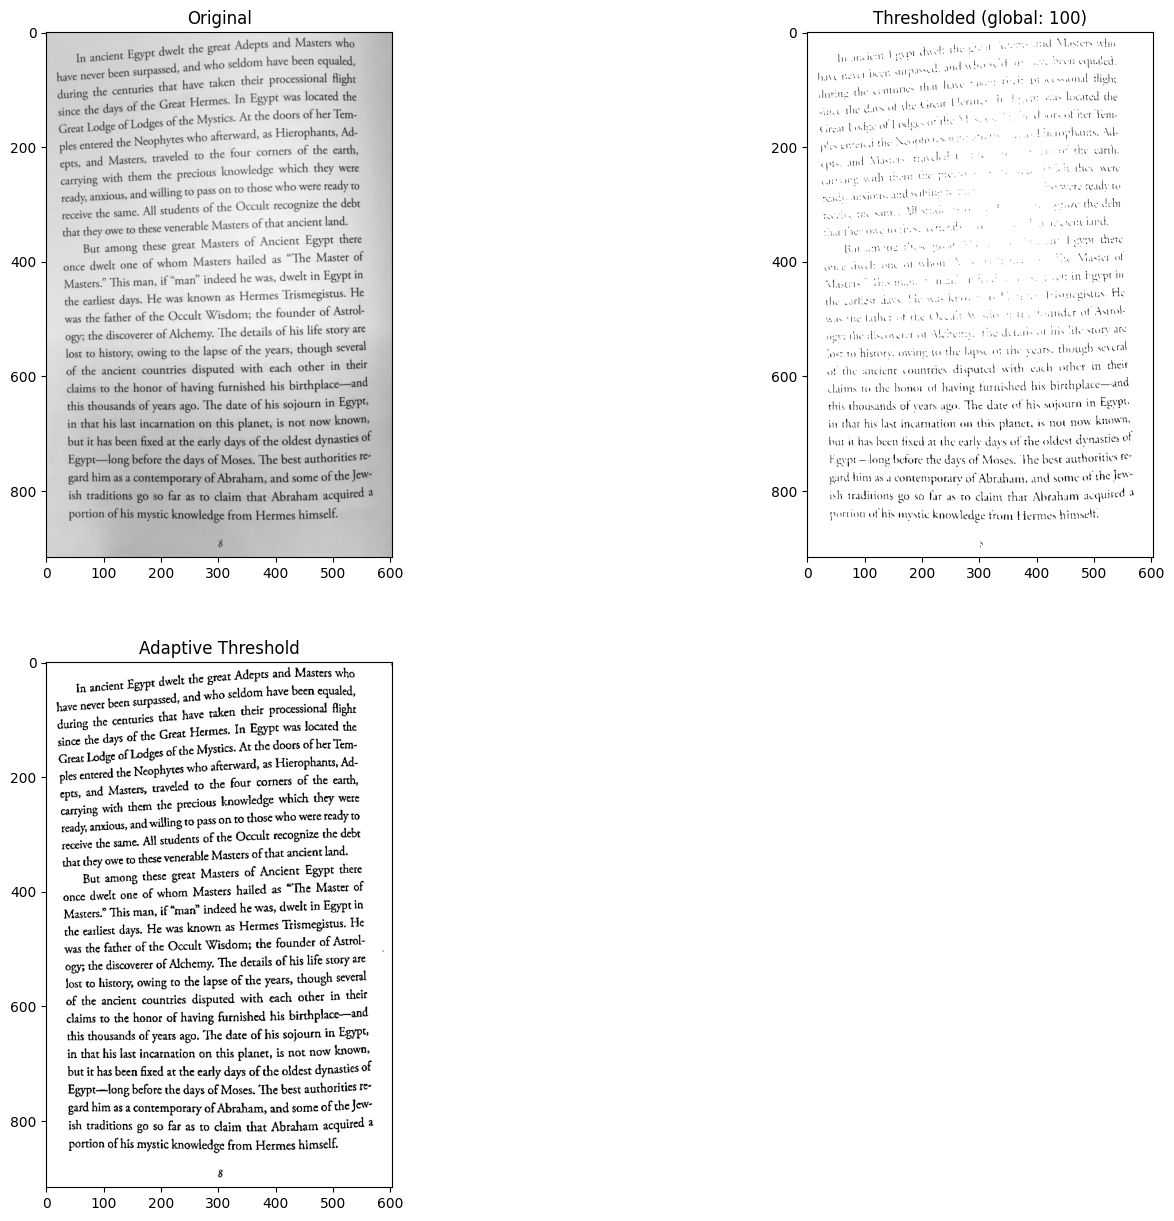

In [247]:
#Adaptive threshold practice
img = cv2.imread('../../DATA/test.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Threshold
retval, img_thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

#Adaptive threshold
img_adaptive_thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img, cmap="gray"); plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh,cmap="gray"); plt.title("Thresholded (global: 100)")
plt.subplot(223); plt.imshow(img_adaptive_thresh,cmap="gray"); plt.title("Adaptive Threshold")

## Bitwise Operations

### <font style="color:rgb(8,133,37)">Function Syntax</font>

Example API for `cv2.bitwise_and()`. Others include: `cv2.bitwise_or()`, `cv2.bitwise_xor()`, `cv2.bitwise_not()`

``` python
dst = cv2.bitwise_and( src1, src2[, dst[, mask]] )
```

`dst`: Output array that has the same size and type as the input arrays.

The function has **2 required arguments**:

1. `src1`:	first input array or a scalar.

2. `src2`:	second input array or a scalar.

An important optional argument is:

1. `mask`:	optional operation mask, 8-bit single channel array, that specifies elements of the output array to be changed.


### <font style="color:rgb(8,133,37)">OpenCV Documentation</font>

1. <a href="https://docs.opencv.org/4.5.1/d0/d86/tutorial_py_image_arithmetics.html" target="_blank">Arithmetic Operations on Images</a>

2. <a href="https://docs.opencv.org/4.5.0/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14" target="_blank">bitwise_and(...) function</a>

(200, 499)


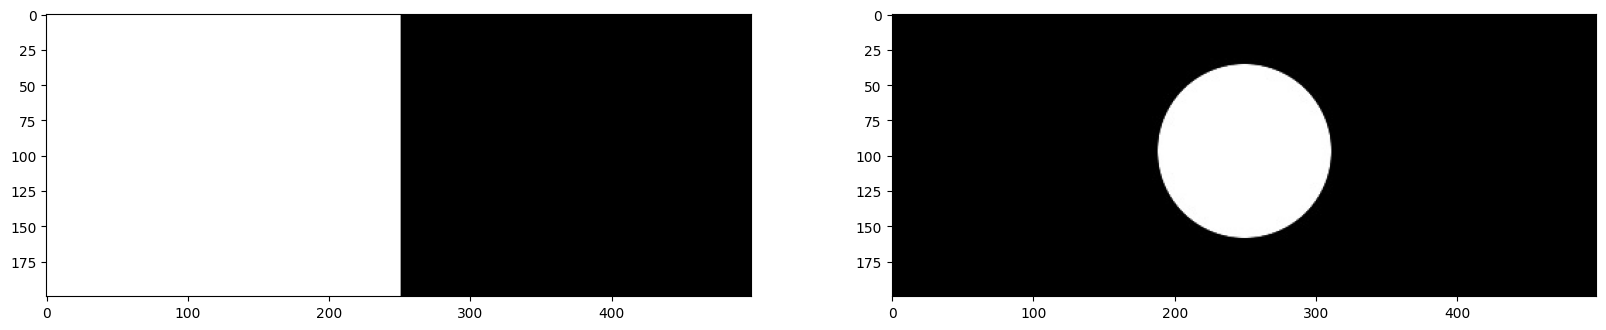

In [248]:
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)

img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)

Text(0.5, 1.0, 'NOT operator')

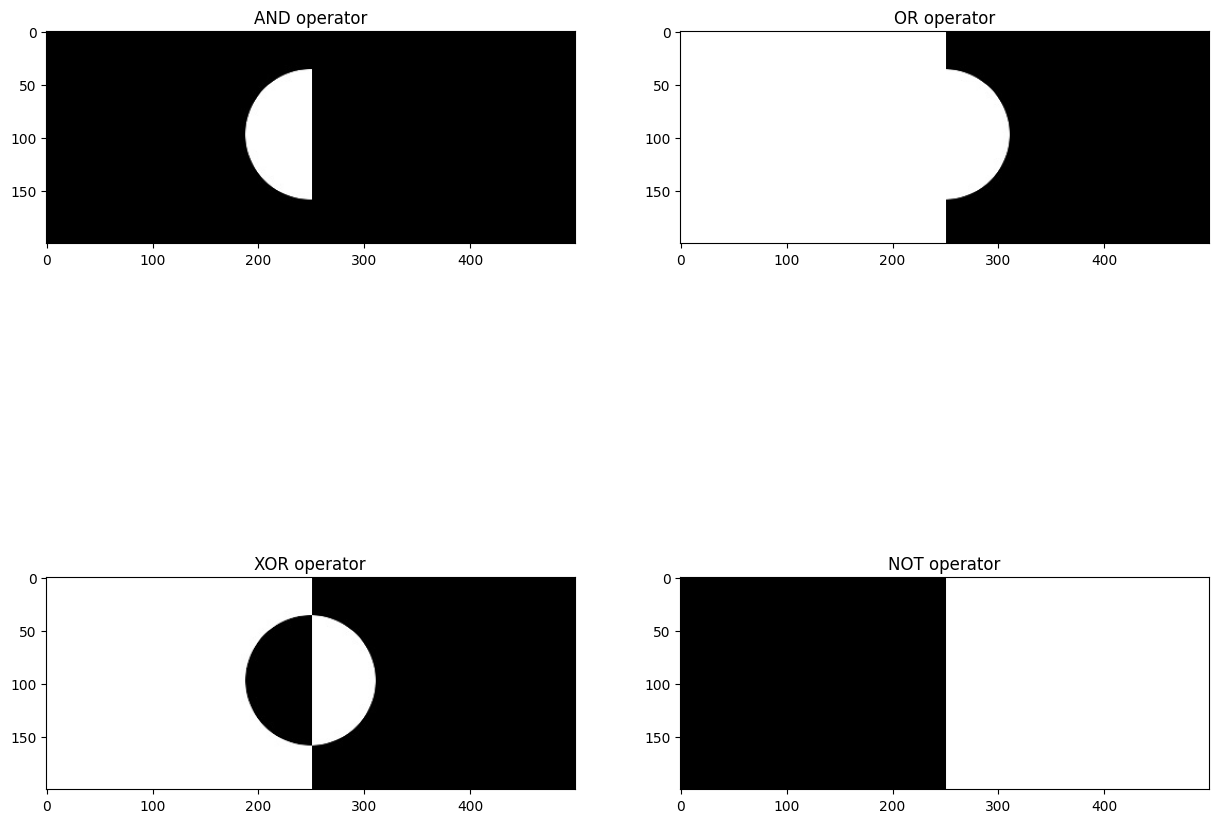

In [249]:
#Bitwise operator
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)

img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)

result_and = cv2.bitwise_and(img_rec, img_cir, mask=None)
result_or = cv2.bitwise_or(img_rec, img_cir, mask=None)
result_xor = cv2.bitwise_xor(img_rec, img_cir, mask=None)
result_not = cv2.bitwise_not(img_rec, img_cir, mask=None)

plt.figure(figsize=[15,13])
plt.subplot(221) ; plt.imshow(result_and, cmap='gray'); plt.title('AND operator')
plt.subplot(222); plt.imshow(result_or, cmap='gray'); plt.title('OR operator')
plt.subplot(223); plt.imshow(result_xor, cmap='gray'); plt.title('XOR operator')
plt.subplot(224); plt.imshow(result_not, cmap='gray'); plt.title('NOT operator')